In [ ]:
# ============================================
# STEP 1: Setup environment
# ============================================
!pip install -q kaggle tensorflow matplotlib scikit-learn

import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

print("✅ TensorFlow version:", tf.__version__)
print("✅ GPU Available:", tf.config.list_physical_devices('GPU'))


✅ TensorFlow version: 2.19.0
✅ GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================
# STEP 2: Download dataset from Kaggle
# ============================================

# 👉 Upload your kaggle.json from https://www.kaggle.com/settings
from google.colab import files
files.upload()  # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# ✅ Download the dataset
!kaggle datasets download -d warcoder/tyre-quality-classification -p /content

# ✅ Unzip it
!unzip -q /content/tyre-quality-classification.zip -d /content/tyre_data

# Verify structure
!ls /content/tyre_data


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/warcoder/tyre-quality-classification
License(s): Attribution 4.0 International (CC BY 4.0)
 99% 2.64G/2.66G [00:29<00:00, 43.3MB/s]
100% 2.66G/2.66G [00:29<00:00, 96.3MB/s]
'Digital images of defective and good condition tyres'


In [ ]:
import os
import shutil
import random

BaseDir     = '/content/tyre_data/Digital images of defective and good condition tyres'
Classes     = ['good', 'defective']
TrainRatio  = 0.8

for cls in Classes:
    src_dir  = os.path.join(BaseDir, cls)
    images   = os.listdir(src_dir)
    random.shuffle(images)

    train_count = int(len(images) * TrainRatio)

    train_images = images[:train_count]
    val_images   = images[train_count:]

    train_cls_dir = os.path.join(BaseDir, 'train', cls)
    val_cls_dir   = os.path.join(BaseDir, 'val',   cls)

    os.makedirs(train_cls_dir, exist_ok=True)
    os.makedirs(val_cls_dir,   exist_ok=True)

    for img in train_images:
        shutil.move(os.path.join(src_dir, img), os.path.join(train_cls_dir, img))

    for img in val_images:
        shutil.move(os.path.join(src_dir, img), os.path.join(val_cls_dir, img))


In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ============================================
# STEP 1: Define dataset base path
# ============================================

# Update this to your dataset path
BASE_DIR = "/content/tyre_data/Digital images of defective and good condition tyres/"  # or /content/tyre-quality-classification if uploaded manually

# If the dataset does NOT have train/val split, create them first using the script I shared earlier
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")

# ============================================
# STEP 2: Define image parameters
# ============================================
IMG_WIDTH = 224
IMG_HEIGHT = 224
BATCH_SIZE = 32

# ============================================
# STEP 3: Create ImageDataGenerators
# ============================================

train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
    rescale=1./255
)

val_datagen = ImageDataGenerator(rescale=1./255)


In [ ]:
TRAIN_DIR = '/content/tyre_data/Digital images of defective and good condition tyres/train'
VAL_DIR   = '/content/tyre_data/Digital images of defective and good condition tyres/val'

IMG_WIDTH = 224
IMG_HEIGHT = 224
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',      # since 2 classes
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 1484 images belonging to 2 classes.
Found 372 images belonging to 2 classes.


In [ ]:
# ============================================
# STEP 5: Define reusable build_and_train function
# ============================================

def build_and_train(base_model_class, model_name, input_shape=(224,224,3), epochs=10):
    print(f"\n🔹 Training {model_name}...\n")

    # Load base model (pretrained on ImageNet)
    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=input_shape)

    # Add custom layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    # Freeze base model layers
    for layer in base_model.layers:
        layer.trainable = False

    # Compile
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Callbacks
    checkpoint = ModelCheckpoint(
        os.path.join("/content/", f"{model_name}_best.h5"),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )

    earlystop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1)

    # Train
    history = model.fit(
        train_generator,
        epochs=epochs,
        validation_data=val_generator,
        callbacks=[checkpoint, earlystop, reduce_lr],
        verbose=1
    )

    # Plot accuracy/loss
    plt.figure(figsize=(12,5))
    plt.suptitle(f"{model_name} Performance", fontsize=16)

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.legend(); plt.title('Accuracy')

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend(); plt.title('Loss')

    plt.show()

    # Return history for later comparison
    return history



🔹 Training MobileNetV2...

Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6306 - loss: 0.6897
Epoch 1: val_accuracy improved from -inf to 0.80376, saving model to /content/MobileNetV2_best.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.6321 - loss: 0.6877 - val_accuracy: 0.8038 - val_loss: 0.4161 - learning_rate: 0.0010
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8080 - loss: 0.4585
Epoch 2: val_accuracy improved from 0.80376 to 0.81720, saving model to /content/MobileNetV2_best.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8081 - loss: 0.4579 - val_accuracy: 0.8172 - val_loss: 0.3549 - learning_rate: 0.0010
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7956 - loss: 0.3998
Epoch 3: val_accuracy improved from 0.81720 to 0.84946, saving model to /content/MobileNetV2_best.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.7959 - loss: 0.3995 - val_accuracy: 0.8495 - val_loss: 0.3246 - learning_rate: 0.0010
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8320 - loss: 0.3655
Epoch 4: val_accuracy did not improve from 0.84946
47/47 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.8322 - loss: 0.3653 - val_accuracy: 0.8495 - val_loss: 0.3469 - learning_rate: 0.0010
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8433 - loss: 0.3491
Epoch 5: val_accuracy improved from 0.84946 to 0.85484, saving model to /content/MobileNetV2_best.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8433 - loss: 0.3488 - val_accuracy: 0.8548 - val_loss: 0.3002 - learning_rate: 0.0010
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8696 - loss: 0.2891
Epoch 6: val_accuracy improved from 0.85484 to 0.86290, saving model to /content/MobileNetV2_best.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8693 - loss: 0.2897 - val_accuracy: 0.8629 - val_loss: 0.2910 - learning_rate: 0.0010
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8725 - loss: 0.3019
Epoch 7: val_accuracy improved from 0.86290 to 0.87097, saving model to /content/MobileNetV2_best.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8726 - loss: 0.3017 - val_accuracy: 0.8710 - val_loss: 0.2797 - learning_rate: 0.0010
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8749 - loss: 0.3039
Epoch 8: val_accuracy did not improve from 0.87097
47/47 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8750 - loss: 0.3037 - val_accuracy: 0.8683 - val_loss: 0.2854 - learning_rate: 0.0010
Epoch 9/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8854 - loss: 0.2736
Epoch 9: val_accuracy did not improve from 0.87097
47/47 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8853 - loss: 0.2735 - val_accuracy: 0.8683 - val_loss: 0.2748 - learning_rate: 0.0010
Epoch 10/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8770 - loss: 0.2779
Epoch 10: val_accuracy did not improve from 0.87097
47/47 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8771 - loss: 0.2778 - val_accuracy: 0.8710 - val_loss: 0.2736 - learning_rate: 0.0010


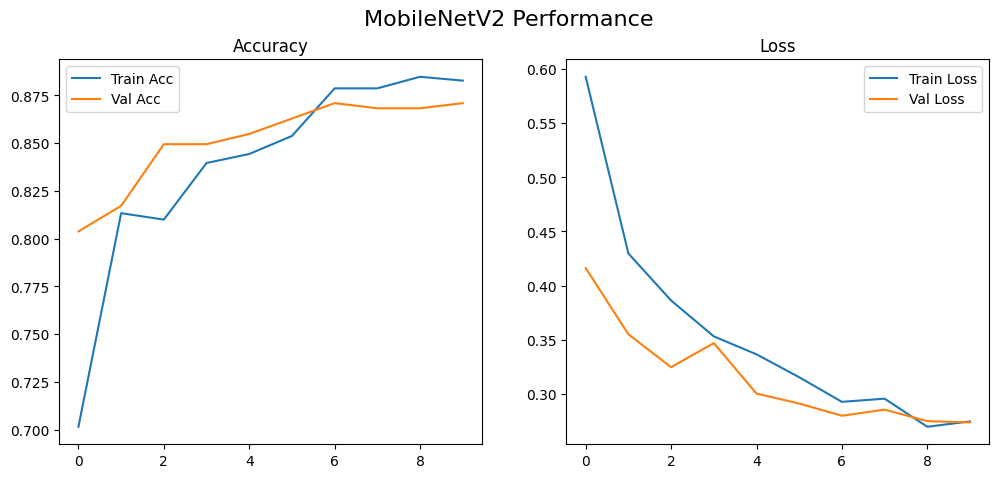

In [ ]:
# ============================================
# STEP 6: Train different models
# ============================================
from tensorflow.keras.applications import MobileNetV2, InceptionV3, VGG16, EfficientNetB0

histories = {}

# You can test one model first (for speed)
histories["MobileNetV2"] = build_and_train(MobileNetV2, "MobileNetV2")


In [ ]:
from tensorflow.keras.models import load_model

# Load your previously trained model
model = load_model("/content/MobileNetV2_best.h5")

print("✅ Loaded previous model successfully.")

# Unfreeze top layers for fine-tuning
for layer in model.layers[-5:]:
    layer.trainable = True

# Recompile with a smaller learning rate
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss="binary_crossentropy",
              metrics=["accuracy"])

print("✅ Top 20 layers unfrozen and model ready for fine-tuning.")


fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    verbose=1
)



✅ Loaded previous model successfully.
✅ Top 20 layers unfrozen and model ready for fine-tuning.
Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.8073 - loss: 0.4284 - val_accuracy: 0.8656 - val_loss: 0.2802
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.8100 - loss: 0.4125 - val_accuracy: 0.8683 - val_loss: 0.2810
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.8198 - loss: 0.4014 - val_accuracy: 0.8629 - val_loss: 0.2821
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.8331 - loss: 0.3704 - val_accuracy: 0.8602 - val_loss: 0.2830
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.8375 - loss: 0.3610 - val_accuracy: 0.8575 - val_loss: 0.2841
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8614 - loss: 0.3359 - val_accuracy: 0.8522 - val_loss: 0.2845
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.8327 - loss: 0.3494 - val_accuracy: 0.8548 - val_loss: 0.2853
Epoch 8/10
47/47 ━━━━

In [ ]:
val_loss, val_acc = model.evaluate(val_generator)
print(f"Final Fine-Tuned Validation Accuracy: {val_acc:.4f}")


12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8605 - loss: 0.2562
Final Fine-Tuned Validation Accuracy: 0.8522


In [ ]:
# ============================================
# STEP 7: Compare final accuracies
# ============================================
for name, hist in histories.items():
    print(f"{name}: Final Val Accuracy = {hist.history['val_accuracy'][-1]:.4f}")


MobileNetV2: Final Val Accuracy = 0.8710


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


✅ Model loaded successfully!
✅ Last convolutional layer: Conv_1
🖼️ Selected 5 images for Grad-CAM visualization


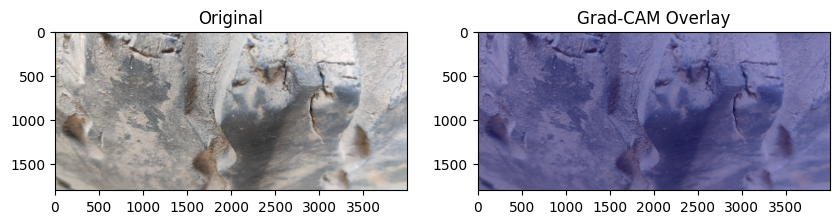

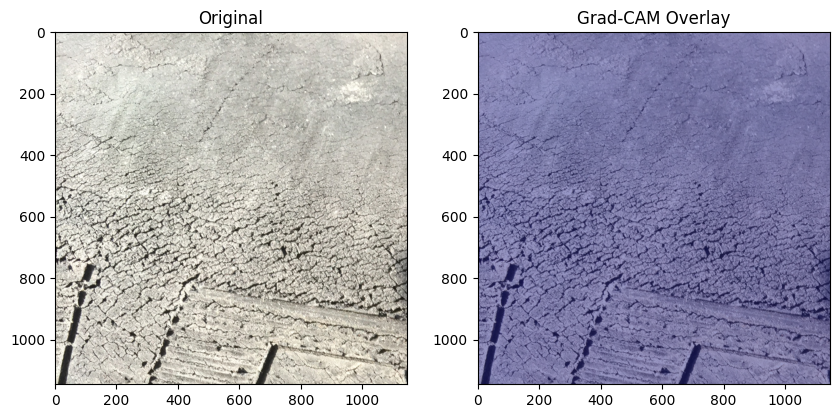

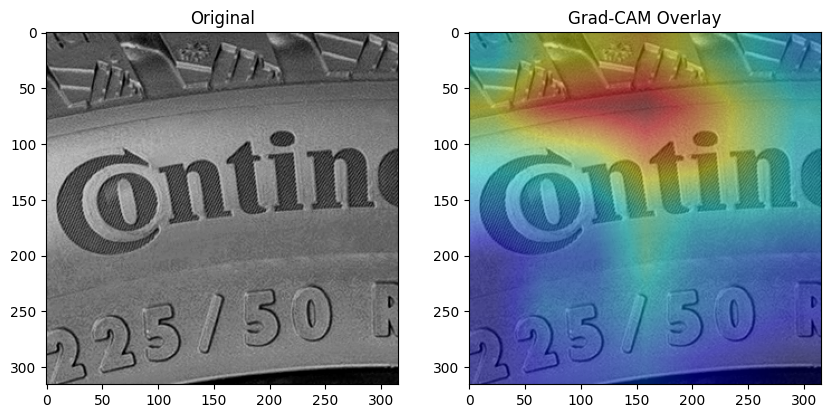

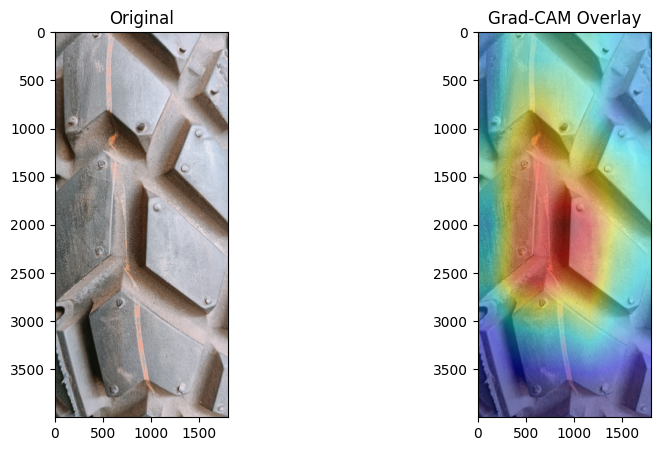

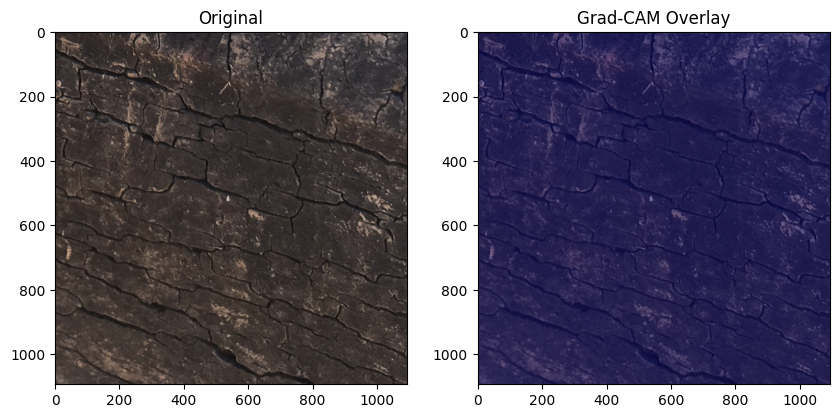

✅ All 5 Grad-CAM images generated and saved in /content/gradcam_results/


In [ ]:
# ✅ STEP 1: Imports
import tensorflow as tf
import numpy as np
import cv2
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Conv2D, DepthwiseConv2D

# ✅ STEP 2: Load model
model_path = "/content/MobileNetV2_best.h5"
model = load_model(model_path)
print("✅ Model loaded successfully!")

# ✅ STEP 3: Find the last convolutional layer automatically
last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, (Conv2D, DepthwiseConv2D)):
        last_conv_layer_name = layer.name
        break

if last_conv_layer_name is None:
    raise ValueError("No convolutional layer found in model!")

print("✅ Last convolutional layer:", last_conv_layer_name)

# ✅ STEP 4: Grad-CAM function (Fixed)
def grad_cam(model, img_array, layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    # Normalize heatmap
    heatmap = np.maximum(heatmap, 0)
    max_val = np.max(heatmap)
    if max_val == 0:
        return heatmap
    heatmap /= max_val
    return heatmap  # ✅ Already NumPy, no .numpy() needed!

# ✅ STEP 5: Pick 5 random images from validation set
val_filepaths = val_generator.filepaths
selected_paths = random.sample(val_filepaths, 5)
print("🖼️ Selected 5 images for Grad-CAM visualization")

# ✅ STEP 6: Create directory for saving results
os.makedirs("/content/gradcam_results", exist_ok=True)

# ✅ STEP 7: Generate Grad-CAM overlays for 5 images
for idx, img_path in enumerate(selected_paths):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    # Generate Grad-CAM
    heatmap = grad_cam(model, img_array, last_conv_layer_name)

    # Load original image
    img_cv = cv2.imread(img_path)
    heatmap = cv2.resize(heatmap, (img_cv.shape[1], img_cv.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img_cv, 0.6, heatmap, 0.4, 0)

    # Save overlay
    save_path = f"/content/gradcam_results/gradcam_{idx+1}.jpg"
    cv2.imwrite(save_path, superimposed_img)

    # Display
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    plt.title("Original")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM Overlay")
    plt.show()

print("✅ All 5 Grad-CAM images generated and saved in /content/gradcam_results/")


✅ Model loaded successfully


Saving IMG_20250925_162258.jpg to IMG_20250925_162258.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Confidence: 89.64 %
Raw Prediction Score: 0.10358616
🔴 Prediction: BAD IMAGE


(np.float64(-0.5), np.float64(2591.5), np.float64(4607.5), np.float64(-0.5))

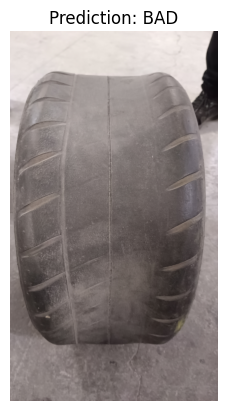

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/MobileNetV2_best.h5")
print("✅ Model loaded successfully")

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()
image_name = list(uploaded.keys())[0]

img = cv2.imread(image_name)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')

IMG_SIZE = 224

def preprocess_image(img):
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    return img

processed_img = preprocess_image(img)

prediction = model.predict(processed_img)[0][0]

confidence = prediction*100 if prediction>0.5 else (1-prediction)*100
print("Confidence:", round(confidence,2), "%")


print("Raw Prediction Score:", prediction)


if prediction > 0.5:
    print("🟢 Prediction: GOOD IMAGE")
else:
    print("🔴 Prediction: BAD IMAGE")


label = "GOOD" if prediction > 0.5 else "BAD"

plt.imshow(img_rgb)
plt.title(f"Prediction: {label}")
plt.axis('off')
